# Active Reset Protocol: TLS-Qubit System

1. **Active reset protocol** — TLS is repeatedly forced back to $P_t=1$ every fixed interval $\Delta t$, while the qubit evolves freely and accumulates population
2. **Ensemble comparison** — both protocols (active reset vs free evolution) run over 30 independent shots with randomized initial qubit population $P_q^{(0)} \sim \mathcal{U}[0,1]$

## 1. Physical Setup

### The Hamiltonian

Under the rotating wave approximation ($\hbar = 1$):

$$H = \frac{\omega_q}{2}\sigma_z^{(q)} + \frac{\omega_t}{2}\sigma_z^{(t)} + g\left(\sigma_+^{(q)}\sigma_-^{(t)} + \sigma_-^{(q)}\sigma_+^{(t)}\right)$$

The exchange term $g(\sigma_+^{(q)}\sigma_-^{(t)} + \text{h.c.})$ allows excitation to hop between qubit and TLS at rate $g$.

### Lindblad master equation

$$\dot{\rho} = -i[H,\rho] + \gamma_q(1+n_{th})\mathcal{D}[\sigma_-^q] + \gamma_q n_{th}\mathcal{D}[\sigma_+^q] + \gamma_t(1+n_{th})\mathcal{D}[\sigma_-^t] + \gamma_t n_{th}\mathcal{D}[\sigma_+^t] + \frac{\gamma_\phi^q}{2}\mathcal{D}[\sigma_z^q] + \frac{\gamma_\phi^t}{2}\mathcal{D}[\sigma_z^t]$$

where $\mathcal{D}[L]\rho = L\rho L^\dagger - \frac{1}{2}\{L^\dagger L, \rho\}$. The $\mathcal{D}[L]$ describe the dissipative operators in Krauss representation. 

### Solomon rate equations

In the limit $g \ll \gamma_t$ (Markovian/incoherent transfer), the coherences vanish and populations obey:

$$\dot{P}_q = -\gamma_q(2n_{th}+1)(P_q - P_q^{ss}) - \Gamma(P_q - P_t)$$
$$\dot{P}_t = -\gamma_t(2n_{th}+1)(P_t - P_t^{ss}) + \Gamma(P_q - P_t)$$

with exchange rate:

$$\Gamma = \frac{2g^2\gamma_{t,eff}}{\Delta^2 + \gamma_{t,eff}^2}, \qquad \gamma_{t,eff} = \gamma_t(2n_{th}+1) + \gamma_\phi^t$$

and thermal steady state $P^{ss} = n_{th}/(2n_{th}+1)$.

## 2. Initialization vs Active Reset

### Initialization
Set the system state once at $t=0$ and let it evolve freely:
$$\rho(0) = \rho_0, \qquad \rho(t) = \mathcal{E}_t[\rho_0]$$

### Active Reset
Every interval $\Delta t$, the TLS is **forcibly returned** to its excited state while the qubit is left untouched:

$$\text{Cycle } n: \quad P_q^{(n)} \to \text{unchanged}, \quad P_t^{(n)} \to 1$$

After $N$ cycles the qubit has accumulated population from $N$ separate TLS excitations. The protocol models a TLS that is **continuously re-excited** by its environment such as charge fluctuators in CPB's etc.

### Why no coherences between cycles?

The active reset operation destroys all qubit-TLS coherences $\rho_{eg,ge}$ — it projects the TLS onto a specific state. Between cycles the density matrix is diagonal in the population basis:

$$\rho^{reset} = P_q P_t |ee\rangle\langle ee| + P_q(1-P_t)|eg\rangle\langle eg| + (1-P_q)P_t|ge\rangle\langle ge| + \ldots$$

with $P_t = 1$ forced at each reset.

## 3. Parameters

In [3]:
import sys
sys.path.insert(0, '../simulations')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import qutip as qt
%matplotlib inline

from qubit_tls.lindblad import evolve as lindblad_evolve
from qubit_tls.solomon  import evolve as solomon_evolve
from utils.physics import make_params, gamma_phi_from_T2

In [4]:

N_TH = 0.1   # thermal photon number (~50 mK for 5 GHz qubit)

PARAMS = make_params(
    wq      = 1.0,
    wt      = 1.0,       # resonant: Delta=0
    gamma_q = 0.01,      # T1_q = 100
    gamma_t = 0.005,     # T1_t = 200
    T2_q    = 50.0,      # T2_q = T1/2 → gamma_phi_q = 0.030
    T2_t    = 100.0,     # T2_t = T1/2 → gamma_phi_t = 0.010
    n_th_q  = N_TH,
    n_th_t  = N_TH,
)

P_SS = N_TH / (2*N_TH + 1)   # thermal steady state

print(f"Parameters:")
print(f"  gamma_q   = {PARAMS['gamma_q']:.4f}   T1_q = {PARAMS['T1_q']:.0f}")
print(f"  gamma_t   = {PARAMS['gamma_t']:.4f}   T1_t = {PARAMS['T1_t']:.0f}")
print(f"  gamma_phi_q = {PARAMS['gamma_phi_q']:.4f}   T2_q = {PARAMS['T2_q']:.0f}")
print(f"  gamma_phi_t = {PARAMS['gamma_phi_t']:.4f}   T2_t = {PARAMS['T2_t']:.0f}")
print(f"  n_th = {N_TH}   P_ss = {P_SS:.4f}")

FIXED = {k: PARAMS[k] for k in
         ['wq','wt','gamma_q','gamma_t','gamma_phi_q','gamma_phi_t',
          'n_th_q','n_th_t']}

# Coupling values: g/gamma_t = 0.5 (valid), 0.7, 0.8 (solomon vs. lindblad threshold region)
G_VALUES = [0.0025, 0.0035, 0.0040]
G_LABELS = ['$g/\\gamma_t=0.5$ (Solomon valid)',
             '$g/\\gamma_t=0.7$ (threshold)',
             '$g/\\gamma_t=0.8$ (Solomon breaking)']
COLORS   = ['C0', 'C1', 'C2']

# Reset protocol
N_CYCLES = 20
DT       = 100
N_STEPS  = 200

Parameters:
  gamma_q   = 0.0100   T1_q = 100
  gamma_t   = 0.0050   T1_t = 200
  gamma_phi_q = 0.0300   T2_q = 50
  gamma_phi_t = 0.0150   T2_t = 100
  n_th = 0.1   P_ss = 0.0833


## 4. Active Reset: Single Shot

TLS starts at $P_t=1$, qubit at $P_q=0$. Every $\Delta t = 100$ the TLS is reset to 1. The qubit accumulates population over 20 cycles.

**Expected behavior:**
- TLS: sawtooth — drops from 1 each cycle, snapped back at reset
- Qubit: staircase — rises a little each cycle, approaching $P_{ss}$ asymptotically
- At larger $g/\gamma_t$: faster qubit charging, larger Lindblad-Solomon discrepancy

In [5]:
def run_active_reset(g, P_q0=0.0, model='lindblad'):
    """Run active reset protocol. TLS reset to 1 every DT."""
    P_q = P_q0
    P_t = 1.0
    t_full, Pq_full, Pt_full = [], [], []
    Pq_end, Pt_end = [], []

    for cycle in range(N_CYCLES):
        t_off = cycle * DT

        if model == 'lindblad':
            rho0 = (P_q*P_t         * qt.ket2dm(qt.tensor(qt.basis(2,0), qt.basis(2,0)))
                  + P_q*(1-P_t)     * qt.ket2dm(qt.tensor(qt.basis(2,0), qt.basis(2,1)))
                  + (1-P_q)*P_t     * qt.ket2dm(qt.tensor(qt.basis(2,1), qt.basis(2,0)))
                  + (1-P_q)*(1-P_t) * qt.ket2dm(qt.tensor(qt.basis(2,1), qt.basis(2,1))))
            res = lindblad_evolve(**FIXED, g=g, t_end=DT, n_steps=N_STEPS, rho0=rho0)
        else:
            res = solomon_evolve(**FIXED, g=g, t_end=DT, n_steps=N_STEPS,
                                P_q0=P_q, P_t0=P_t)

        t_full.extend(res['t'] + t_off)
        Pq_full.extend(res['P_e_q'])
        Pt_full.extend(res['P_e_t'])
        Pq_end.append(res['P_e_q'][-1])
        Pt_end.append(res['P_e_t'][-1])
        P_q = res['P_e_q'][-1]
        P_t = 1.0  # RESET

    return {'t': np.array(t_full), 'Pq': np.array(Pq_full),
            'Pt': np.array(Pt_full), 'Pq_end': np.array(Pq_end),
            'Pt_end': np.array(Pt_end), 'cycles': np.arange(1, N_CYCLES+1)}


# Run for all three g values
results_L = {g: run_active_reset(g, model='lindblad') for g in G_VALUES}
results_S = {g: run_active_reset(g, model='solomon')  for g in G_VALUES}
print('Done.')

Done.


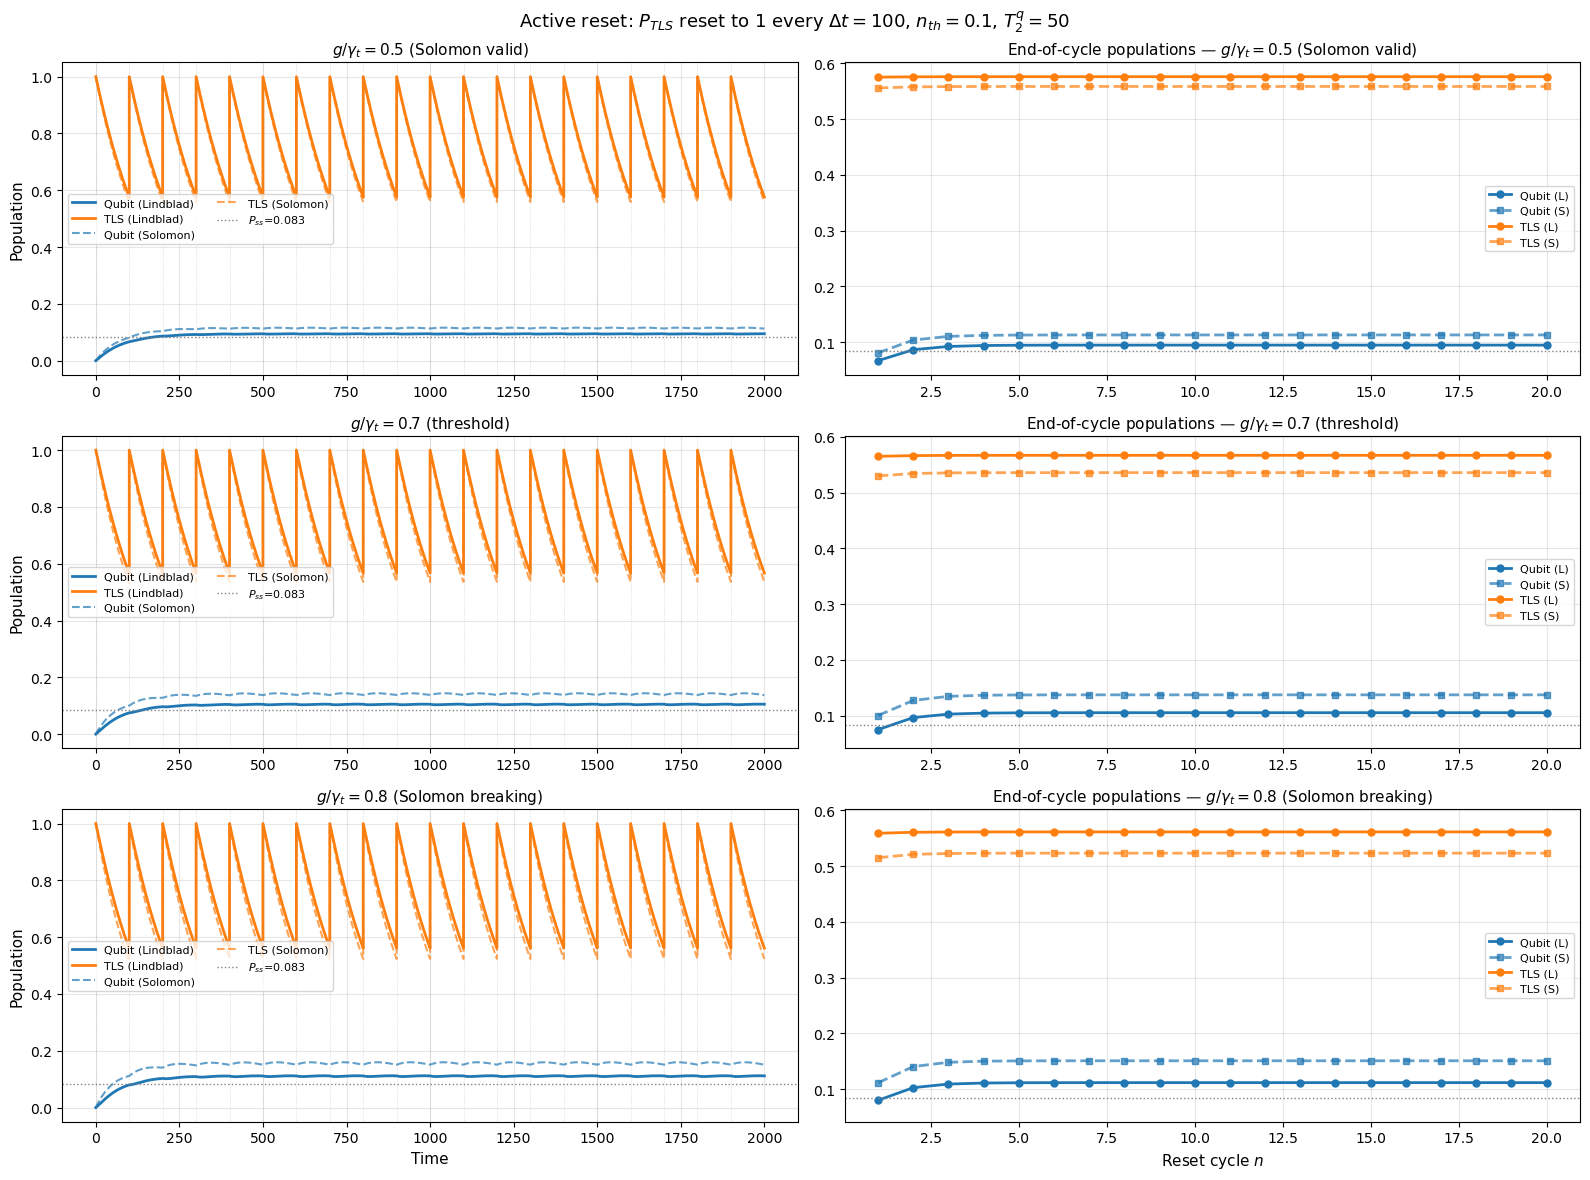

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharey='col')

for row, (g, label, color) in enumerate(zip(G_VALUES, G_LABELS, COLORS)):
    rL = results_L[g]
    rS = results_S[g]

    # Left: full time trace
    ax = axes[row, 0]
    ax.plot(rL['t'], rL['Pq'], lw=2, color='C0', label='Qubit (Lindblad)')
    ax.plot(rL['t'], rL['Pt'], lw=2, color='C1', label='TLS (Lindblad)')
    ax.plot(rS['t'], rS['Pq'], lw=1.5, ls='--', color='C0', alpha=0.7, label='Qubit (Solomon)')
    ax.plot(rS['t'], rS['Pt'], lw=1.5, ls='--', color='C1', alpha=0.7, label='TLS (Solomon)')
    ax.axhline(P_SS, color='gray', ls=':', lw=1, label=f'$P_{{ss}}$={P_SS:.3f}')
    for n in range(N_CYCLES):
        ax.axvline(n*DT, color='gray', ls=':', lw=0.5, alpha=0.4)
    ax.set_ylabel('Population', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
    if row == 2: ax.set_xlabel('Time', fontsize=11)

    # Right: per-cycle end values
    ax2 = axes[row, 1]
    n = rL['cycles']
    ax2.plot(n, rL['Pq_end'], 'o-', lw=2, color='C0', ms=5, label='Qubit (L)')
    ax2.plot(n, rS['Pq_end'], 's--', lw=2, color='C0', ms=5, alpha=0.7, label='Qubit (S)')
    ax2.plot(n, rL['Pt_end'], 'o-', lw=2, color='C1', ms=5, label='TLS (L)')
    ax2.plot(n, rS['Pt_end'], 's--', lw=2, color='C1', ms=5, alpha=0.7, label='TLS (S)')
    ax2.axhline(P_SS, color='gray', ls=':', lw=1)
    ax2.set_title(f'End-of-cycle populations — {label}', fontsize=11)
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    if row == 2: ax2.set_xlabel('Reset cycle $n$', fontsize=11)

fig.suptitle(
    rf'Active reset: $P_{{TLS}}$ reset to 1 every $\Delta t={DT}$, '
    rf'$n_{{th}}={N_TH}$, $T_2^q={PARAMS["T2_q"]:.0f}$',
    fontsize=13)
plt.tight_layout()
plt.savefig('../figures/sweeps/nb01_active_reset_traces.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ensemble: Randomized Initial Qubit Population

We run $N_{shots}=30$ independent realizations, each with a different $P_q^{(0)}$ drawn uniformly from $[0,1]$. The TLS always starts at $P_t=1$.



After $N$ cycles, does the final $P_q$ depend on the initial $P_q^{(0)}$?

- **Correlation $\to 0$:** initial condition erased — system always ends at $P_{ss}$
- **Correlation $\to 1$:** initial condition preserved — no thermalization

The active reset protocol injects energy every $\Delta t$, so it competes with the qubit's natural decay. The question is whether this additional energy injection keeps memory of $P_q^{(0)}$ alive or erases it.

In [7]:
from tqdm.notebook import tqdm

N_SHOTS = 30
rng     = np.random.default_rng(42)
Pq0_values = rng.uniform(0.0, 1.0, N_SHOTS)
G_ENS = 0.0040   # g/gamma_t = 0.8

print(f"Running {N_SHOTS} shots at g/gamma_t={G_ENS/PARAMS['gamma_t']:.2f}...")

all_Pq_reset = []
all_Pt_reset = []
all_Pq_free  = []
all_Pt_free  = []
final_reset  = []
final_free   = []
t_axis       = None

T_TOTAL = N_CYCLES * DT

for Pq0 in tqdm(Pq0_values):
    # Active reset
    rL = run_active_reset(G_ENS, P_q0=Pq0, model='lindblad')
    all_Pq_reset.append(rL['Pq'])
    all_Pt_reset.append(rL['Pt'])
    final_reset.append(rL['Pq_end'][-1])

    # Free evolution (same initial conditions, no reset)
    rho0 = (Pq0*1.0     * qt.ket2dm(qt.tensor(qt.basis(2,0), qt.basis(2,0)))
          + Pq0*0.0     * qt.ket2dm(qt.tensor(qt.basis(2,0), qt.basis(2,1)))
          + (1-Pq0)*1.0 * qt.ket2dm(qt.tensor(qt.basis(2,1), qt.basis(2,0)))
          + (1-Pq0)*0.0 * qt.ket2dm(qt.tensor(qt.basis(2,1), qt.basis(2,1))))
    rF = lindblad_evolve(**FIXED, g=G_ENS, t_end=T_TOTAL,
                         n_steps=N_CYCLES*N_STEPS, rho0=rho0)
    all_Pq_free.append(rF['P_e_q'])
    all_Pt_free.append(rF['P_e_t'])
    final_free.append(rF['P_e_q'][-1])
    if t_axis is None:
        t_axis_reset = rL['t']
        t_axis_free  = rF['t']

all_Pq_reset = np.array(all_Pq_reset)
all_Pt_reset = np.array(all_Pt_reset)
all_Pq_free  = np.array(all_Pq_free)
all_Pt_free  = np.array(all_Pt_free)
final_reset  = np.array(final_reset)
final_free   = np.array(final_free)

corr_reset = np.corrcoef(Pq0_values, final_reset)[0,1]
corr_free  = np.corrcoef(Pq0_values, final_free)[0,1]

print(f"\nMemory erasure after {N_CYCLES} cycles:")
print(f"  Active reset — correlation(final, initial): {corr_reset:.4f}")
print(f"  Free evolution — correlation(final, initial): {corr_free:.4f}")
print(f"  (0 = erased, 1 = perfect memory)")

Running 30 shots at g/gamma_t=0.80...


  0%|          | 0/30 [00:00<?, ?it/s]


Memory erasure after 20 cycles:
  Active reset — correlation(final, initial): 0.9997
  Free evolution — correlation(final, initial): 0.9093
  (0 = erased, 1 = perfect memory)


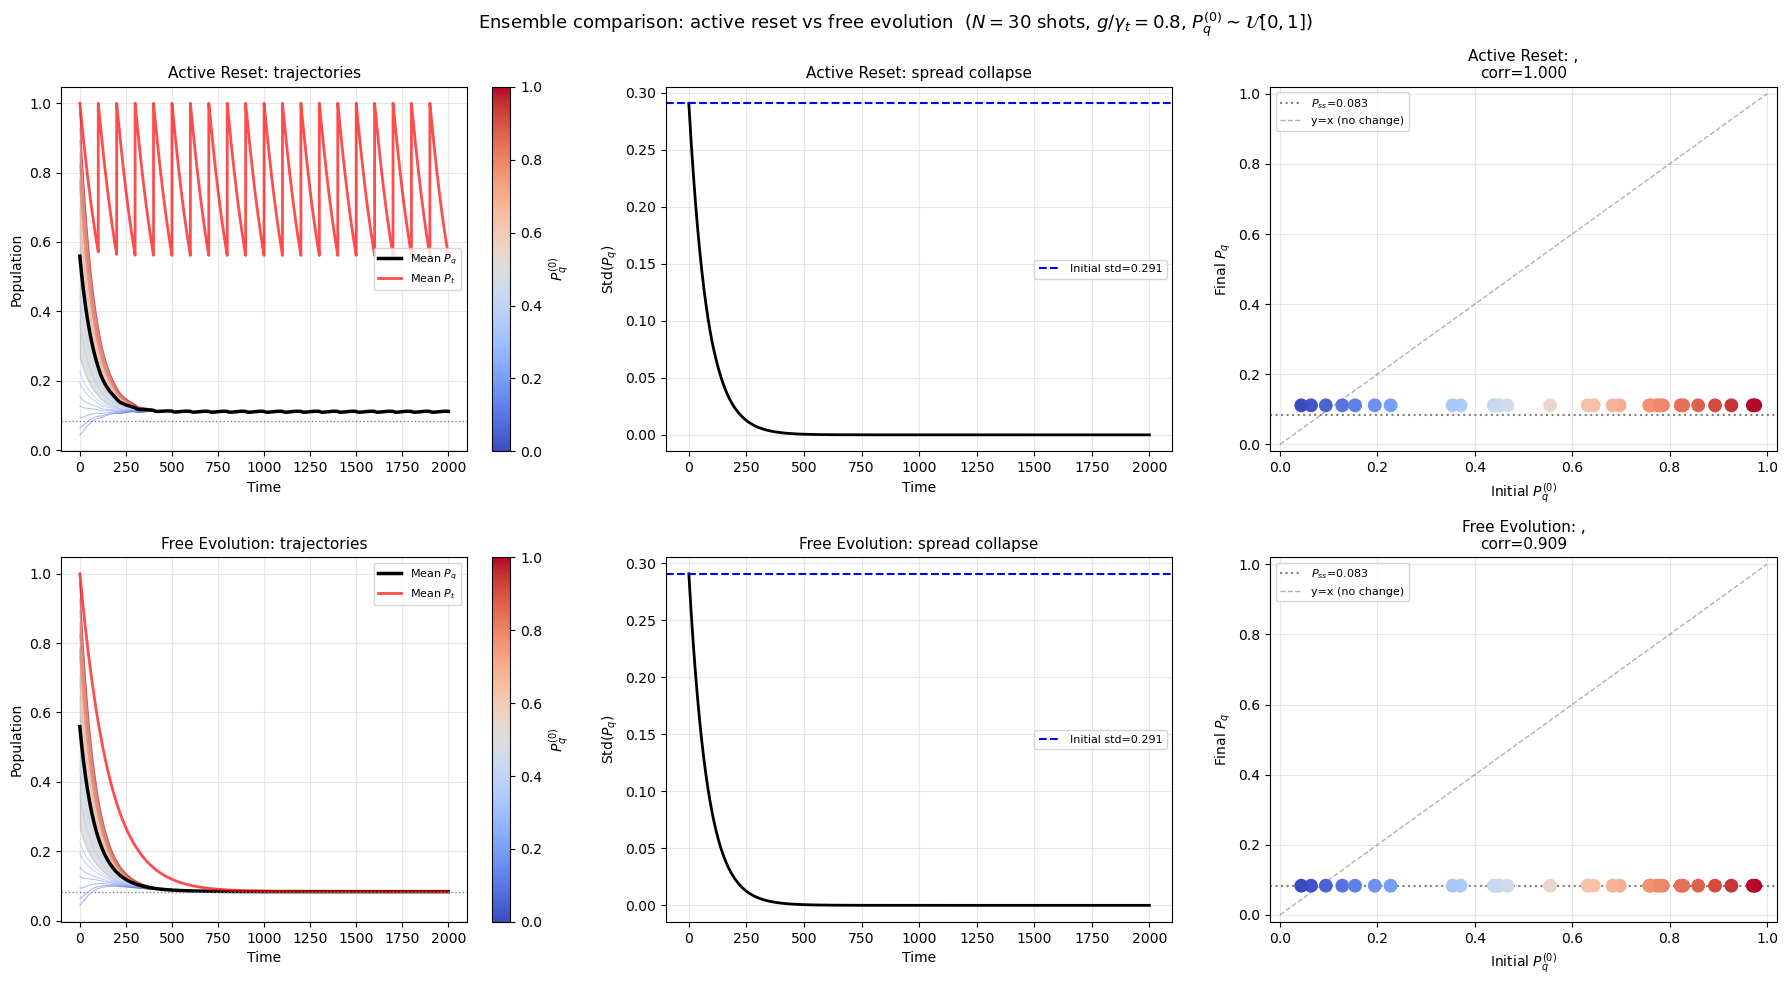

In [9]:
cmap = plt.cm.coolwarm
norm = plt.Normalize(0, 1)
sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sort_idx = np.argsort(Pq0_values)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (arr_Pq, arr_Pt, t_ax, final, corr, title) in enumerate([
    (all_Pq_reset, all_Pt_reset, t_axis_reset, final_reset, corr_reset, 'Active Reset'),
    (all_Pq_free,  all_Pt_free,  t_axis_free,  final_free,  corr_free,  'Free Evolution'),
]):
    # Trajectories
    ax = axes[row, 0]
    for i in sort_idx:
        c = cmap(norm(Pq0_values[i]))
        ax.plot(t_ax, arr_Pq[i], color=c, lw=0.7, alpha=0.5)
    Pq_mean = arr_Pq.mean(axis=0)
    Pq_std  = arr_Pq.std(axis=0)
    Pt_mean = arr_Pt.mean(axis=0)
    ax.fill_between(t_ax, Pq_mean-Pq_std, Pq_mean+Pq_std,
                   color='black', alpha=0.12)
    ax.plot(t_ax, Pq_mean, 'k-', lw=2.5, label='Mean $P_q$')
    ax.plot(t_ax, Pt_mean, 'r-', lw=2, alpha=0.7, label='Mean $P_t$')
    ax.axhline(P_SS, color='gray', ls=':', lw=1)
    plt.colorbar(sm, ax=ax, label='$P_q^{(0)}$')
    ax.set_xlabel('Time'); ax.set_ylabel('Population')
    ax.set_title(f'{title}: trajectories', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Std over time
    ax2 = axes[row, 1]
    ax2.plot(t_ax, Pq_std, 'k-', lw=2)
    ax2.axhline(Pq0_values.std(), color='blue', ls='--', lw=1.5,
               label=f'Initial std={Pq0_values.std():.3f}')
    ax2.set_xlabel('Time'); ax2.set_ylabel('Std($P_q$)')
    ax2.set_title(f'{title}: spread collapse', fontsize=11)
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

    # Memory erasure
    ax3 = axes[row, 2]
    ax3.scatter(Pq0_values, final, c=Pq0_values, cmap=cmap, s=80, zorder=5)
    ax3.axhline(P_SS, color='gray', ls=':', lw=1.5, label=f'$P_{{ss}}$={P_SS:.3f}')
    ax3.plot([0,1],[0,1], 'k--', lw=1, alpha=0.3, label='y=x (no change)')
    ax3.set_xlabel('Initial $P_q^{(0)}$'); ax3.set_ylabel('Final $P_q$')
    ax3.set_title(f'{title}: ,\ncorr={corr:.3f}', fontsize=11)
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
    ax3.set_xlim(-0.02,1.02); ax3.set_ylim(-0.02,1.02)

fig.suptitle(
    rf'Ensemble comparison: active reset vs free evolution  '
    rf'($N={N_SHOTS}$ shots, $g/\gamma_t={G_ENS/PARAMS["gamma_t"]:.1f}$, '
    rf'$P_q^{{(0)}}\sim\mathcal{{U}}[0,1]$)',
    fontsize=13)
plt.tight_layout()
plt.savefig('../figures/sweeps/nb01_ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()